<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/GVH_Pantheon_Pipeline_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GVH Pantheon Pipeline 0.1

## Objectif

Ce notebook construit un pipeline reproductible pour extraire des observables géométriques GVH à partir du catalogue Pantheon+.

Le but est descriptif et méthodologique : mesurer des signatures géométriques multi-échelles sans imposer d’interprétation physique.

## 1. Introduction

Ce notebook fait partie de la série GVH Dynamic.

Il utilise les données Pantheon+ afin de construire un ensemble d’observables géométriques :

- \(D_T\)
- \(S_T\)
- \(D_c\)
- \(R_{\rm super}\)
- \(A_H\)
- \(B_H\)
- \(\theta_{\rm mean}\)
- \(\theta_{\max}\)
- \(R_{180}\)

Ces observables sont calculées directement à partir des données disponibles, après prétraitement, sans introduire d’hypothèse issue du modèle Volume Partagé.

### Séparation méthodologique

Dans ce notebook :

\[
\text{Pantheon+} \longrightarrow \text{observables GVH}
\]

et non :

\[
\text{Pantheon+} \longrightarrow \text{Volume Partagé}
\]

L’interprétation physique éventuelle sera traitée séparément dans les documents VP-GVH.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


In [3]:
import os

print(os.getcwd())
print()

print(os.listdir())

/content

['.config', 'sample_data']


In [4]:
from google.colab import files
files.upload()

Saving Pantheon+SH0ES.dat to Pantheon+SH0ES.dat


{'Pantheon+SH0ES.dat': b'CID IDSURVEY zHD zHDERR zCMB zCMBERR zHEL zHELERR m_b_corr m_b_corr_err_DIAG MU_SH0ES MU_SH0ES_ERR_DIAG CEPH_DIST IS_CALIBRATOR USED_IN_SH0ES_HF c cERR x1 x1ERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 RA DEC HOST_RA HOST_DEC HOST_ANGSEP VPEC VPECERR MWEBV HOST_LOGMASS HOST_LOGMASS_ERR PKMJD PKMJDERR NDOF FITCHI2 FITPROB m_b_corr_err_RAW m_b_corr_err_VPEC biasCor_m_b biasCorErr_m_b biasCor_m_b_COVSCALE biasCor_m_b_COVADD\n2011fe 51 0.00122 0.00084 0.00122 2e-05 0.00082 2e-05 9.74571 1.51621 28.9987 1.51645 29.177 1 0 -0.1076 0.04008 -0.548188 0.13373 9.58436 0.0327221 2.63181 0.0793177 0.00011378 -0.00052525 -0.00272765 210.774 54.2737 -999 -999 -9 0 250 0.00758935 10.677 -9 55815 0.1071 36 26.8859 0.86447 0.0991 1.496 0.0381 0.005 1 0.003\n2011fe 56 0.00122 0.00084 0.00122 2e-05 0.00082 2e-05 9.80286 1.51723 29.0559 1.51747 29.177 1 0 -0.032895 0.038463 -0.380481 0.0861 9.78448 0.0352442 2.1888 0.0710511 -0.000443845 -0.00150198 -0.00220084 210.774 54.273

In [5]:
# Chemin du fichier Pantheon+
# À modifier si le fichier porte un autre nom

pantheon_file = "Pantheon+SH0ES.dat"

df = pd.read_csv(pantheon_file, sep=r"\s+", comment="#")

print("Données chargées avec succès.")
print("Nombre de lignes :", len(df))
print("Nombre de colonnes :", len(df.columns))

df.head()

Données chargées avec succès.
Nombre de lignes : 1701
Nombre de colonnes : 47


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [6]:
print("Colonnes disponibles :")
for col in df.columns:
    print(col)

Colonnes disponibles :
CID
IDSURVEY
zHD
zHDERR
zCMB
zCMBERR
zHEL
zHELERR
m_b_corr
m_b_corr_err_DIAG
MU_SH0ES
MU_SH0ES_ERR_DIAG
CEPH_DIST
IS_CALIBRATOR
USED_IN_SH0ES_HF
c
cERR
x1
x1ERR
mB
mBERR
x0
x0ERR
COV_x1_c
COV_x1_x0
COV_c_x0
RA
DEC
HOST_RA
HOST_DEC
HOST_ANGSEP
VPEC
VPECERR
MWEBV
HOST_LOGMASS
HOST_LOGMASS_ERR
PKMJD
PKMJDERR
NDOF
FITCHI2
FITPROB
m_b_corr_err_RAW
m_b_corr_err_VPEC
biasCor_m_b
biasCorErr_m_b
biasCor_m_b_COVSCALE
biasCor_m_b_COVADD


In [7]:
required_cols = ["zHD", "m_b_corr", "m_b_corr_err_DIAG", "RA", "DEC", "IDSURVEY"]

missing = [col for col in required_cols if col not in df.columns]

if len(missing) == 0:
    print("Toutes les colonnes nécessaires sont présentes.")
else:
    print("Colonnes manquantes :", missing)

Toutes les colonnes nécessaires sont présentes.


In [8]:
df_required = df[required_cols].copy()

print(df_required.isna().sum())

zHD                  0
m_b_corr             0
m_b_corr_err_DIAG    0
RA                   0
DEC                  0
IDSURVEY             0
dtype: int64


In [9]:
df_required.describe()

,zHD,m_b_corr,m_b_corr_err_DIAG,RA,DEC,IDSURVEY
count,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000
mean,0.221229,19.083629,0.240920,157.247004,6.978712,37.017637
std,0.249271,3.374499,0.098815,117.146180,26.985496,45.916840
min,0.001220,9.745710,0.111583,0.895900,-80.177600,1.000000
25%,0.027730,16.036200,0.178788,40.916900,-4.967300,4.000000
50%,0.163750,20.076300,0.217323,150.305000,0.429400,15.000000
75%,0.328680,21.824800,0.278656,243.224000,23.352800,57.000000
max,2.261370,26.929800,1.517230,359.884000,84.678300,150.000000


N = 1701
Aucune valeur manquante
Colonnes utiles présentes
zHD : 0.00122 → 2.26137
RA : 0.8959 → 359.884
DEC : -80.1776 → 84.6783

In [10]:
# Copie propre des colonnes utiles

df_gvh = df[["CID", "IDSURVEY", "zHD", "m_b_corr", "m_b_corr_err_DIAG", "RA", "DEC"]].copy()

# Tri en redshift croissant

df_gvh = df_gvh.sort_values("zHD").reset_index(drop=True)

print("Données préparées.")
print("Nombre de supernovae :", len(df_gvh))

df_gvh.head()

Données préparées.
Nombre de supernovae : 1701


,CID,IDSURVEY,zHD,m_b_corr,m_b_corr_err_DIAG,RA,DEC
0,2011fe,51,0.00122,9.74571,1.516210,210.774,54.2737
1,2011fe,56,0.00122,9.80286,1.517230,210.774,54.2737
2,2012cg,51,0.00256,11.47030,0.781906,186.803,9.4203
3,2012cg,56,0.00256,11.49190,0.798612,186.803,9.4203
4,1994DRichmond,50,0.00299,11.52270,0.880798,188.510,7.7016


In [11]:
print("Redshift minimum :", df_gvh["zHD"].min())
print("Redshift maximum :", df_gvh["zHD"].max())

print("RA minimum :", df_gvh["RA"].min())
print("RA maximum :", df_gvh["RA"].max())

print("DEC minimum :", df_gvh["DEC"].min())
print("DEC maximum :", df_gvh["DEC"].max())

Redshift minimum : 0.00122
Redshift maximum : 2.26137
RA minimum : 0.8959
RA maximum : 359.884
DEC minimum : -80.1776
DEC maximum : 84.6783


In [12]:
# Variables principales

z = df_gvh["zHD"].values
T = df_gvh["m_b_corr"].values
sigma_T = df_gvh["m_b_corr_err_DIAG"].values
ra = df_gvh["RA"].values
dec = df_gvh["DEC"].values

print("Variables GVH de base construites.")
print("z shape :", z.shape)
print("T shape :", T.shape)
print("sigma_T shape :", sigma_T.shape)

Variables GVH de base construites.
z shape : (1701,)
T shape : (1701,)
sigma_T shape : (1701,)


In [13]:
# Contrôle rapide

print("T minimum :", T.min())
print("T maximum :", T.max())
print("sigma_T moyen :", sigma_T.mean())

T minimum : 9.74571
T maximum : 26.9298
sigma_T moyen : 0.2409197142857143


In [14]:
# Calcul de D_T = |dT/dz|
# Ici T = m_b_corr et z = zHD

dT_dz = np.gradient(T, z)
D_T = np.abs(dT_dz)

df_gvh["D_T"] = D_T

print("D_T calculé avec succès.")
print("D_T moyen :", D_T.mean())
print("D_T médian :", np.median(D_T))
print("D_T maximum :", D_T.max())

D_T calculé avec succès.
D_T moyen : nan
D_T médian : nan
D_T maximum : nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/py

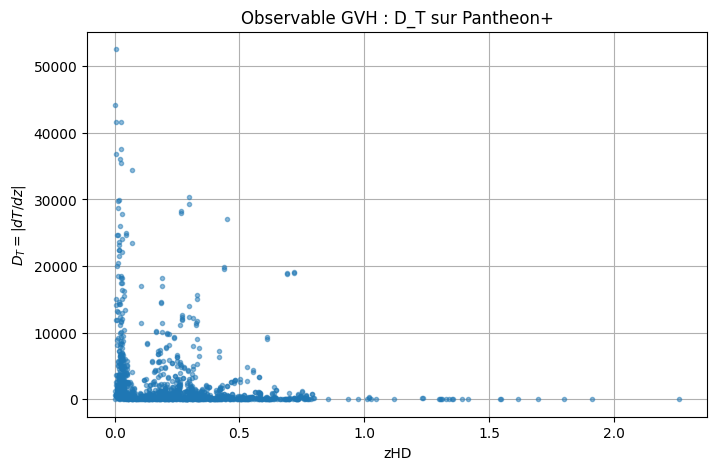

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(z, D_T, ".", alpha=0.5)
plt.xlabel("zHD")
plt.ylabel(r"$D_T = |dT/dz|$")
plt.title("Observable GVH : D_T sur Pantheon+")
plt.grid(True)
plt.show()

In [16]:
# Regrouper les points ayant le même redshift

df_z = (
    df_gvh
    .groupby("zHD", as_index=False)
    .agg({
        "m_b_corr": "mean",
        "m_b_corr_err_DIAG": "mean",
        "RA": "mean",
        "DEC": "mean",
        "IDSURVEY": "first"
    })
)

z_u = df_z["zHD"].values
T_u = df_z["m_b_corr"].values

print("Nombre initial :", len(df_gvh))
print("Nombre après regroupement par z :", len(df_z))

Nombre initial : 1701
Nombre après regroupement par z : 1464


In [17]:
# Calcul stable de D_T = |dT/dz|

dT_dz = np.gradient(T_u, z_u)
D_T = np.abs(dT_dz)

df_z["D_T"] = D_T

print("D_T calculé avec succès.")
print("D_T moyen :", np.mean(D_T))
print("D_T médian :", np.median(D_T))
print("D_T maximum :", np.max(D_T))

D_T calculé avec succès.
D_T moyen : 2876.4799478764703
D_T médian : 645.8675316525166
D_T maximum : 64472.83333333628


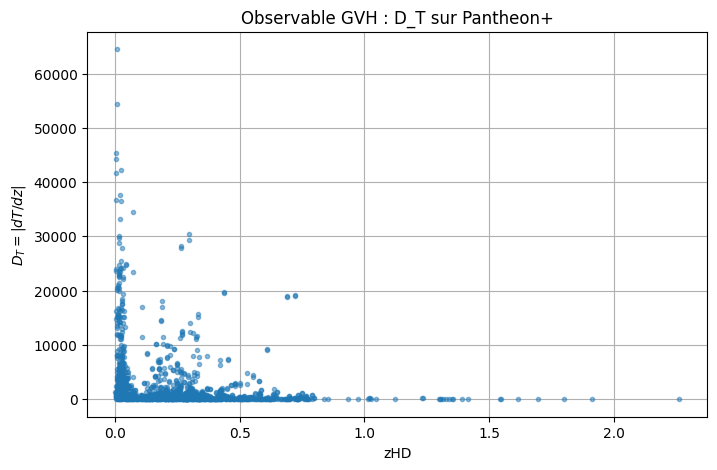

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(z_u, D_T, ".", alpha=0.5)
plt.xlabel("zHD")
plt.ylabel(r"$D_T = |dT/dz|$")
plt.title("Observable GVH : D_T sur Pantheon+")
plt.grid(True)
plt.show()

In [19]:
# Calcul de S_T par fenêtre glissante

window = 11          # nombre de points dans la fenêtre
half = window // 2

S_T = np.zeros(len(T_u))

for i in range(len(T_u)):
    i0 = max(0, i - half)
    i1 = min(len(T_u), i + half + 1)
    S_T[i] = np.std(T_u[i0:i1])

df_z["S_T"] = S_T

print("S_T calculé.")
print("S_T moyen :", np.mean(S_T))
print("S_T médian :", np.median(S_T))
print("S_T maximum :", np.max(S_T))

S_T calculé.
S_T moyen : 0.15053638361763605
S_T médian : 0.13752592264185376
S_T maximum : 0.810158580248095


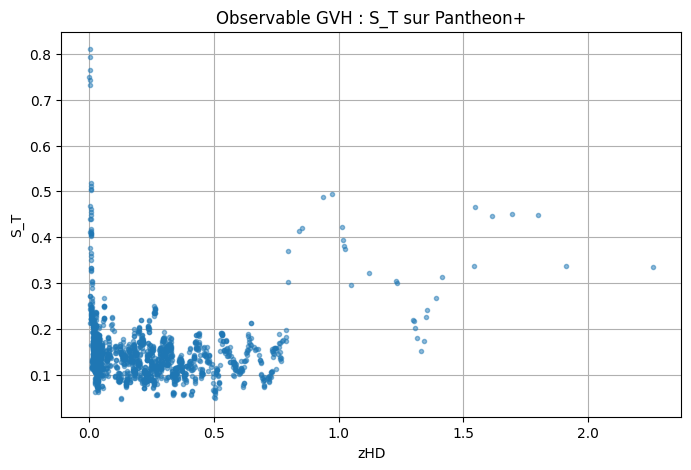

In [20]:
plt.figure(figsize=(8,5))

plt.plot(z_u, S_T, ".", alpha=0.5)

plt.xlabel("zHD")
plt.ylabel("S_T")
plt.title("Observable GVH : S_T sur Pantheon+")

plt.grid(True)
plt.show()

In [21]:
D_c = np.median(D_T) + 2 * np.std(D_T)

df_z["D_c"] = D_c
df_z["supercritical"] = df_z["D_T"] > D_c

print("D_c :", D_c)
print("Nombre de points supercritiques :", df_z["supercritical"].sum())
print("Fraction supercritique :", df_z["supercritical"].mean())

D_c : 12631.612237462954
Nombre de points supercritiques : 92
Fraction supercritique : 0.06284153005464481


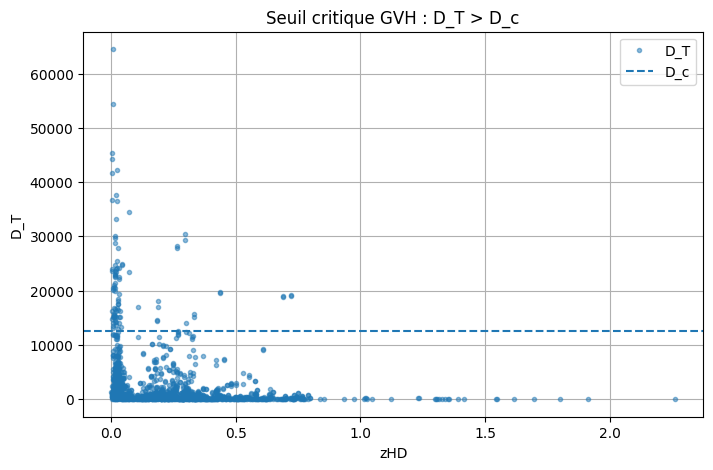

In [22]:
plt.figure(figsize=(8,5))

plt.plot(z_u, D_T, ".", alpha=0.5, label="D_T")
plt.axhline(D_c, linestyle="--", label="D_c")

plt.xlabel("zHD")
plt.ylabel("D_T")
plt.title("Seuil critique GVH : D_T > D_c")

plt.legend()
plt.grid(True)
plt.show()

D_c ≈ 12631.61
Points supercritiques = 92
R_super ≈ 0.06284

In [23]:
R_super = np.mean(D_T > D_c)

print("R_super :", R_super)

R_super : 0.06284153005464481


In [24]:
df_z["R_super"] = R_super

In [25]:
A_H = np.mean(D_T[D_T > D_c])

print("A_H :", A_H)

A_H : 22166.616618694505


In [26]:
df_z["A_H"] = A_H

In [27]:
from scipy.optimize import curve_fit

In [28]:
# Construction d'une gamme de seuils D_c

Dc_values = np.linspace(
    np.percentile(D_T, 50),
    np.percentile(D_T, 99),
    80
)

R_values = []

for Dc in Dc_values:
    R = np.mean(D_T > Dc)
    R_values.append(R)

R_values = np.array(R_values)

print("Courbe R_super(D_c) construite.")
print("Nombre de seuils :", len(Dc_values))

Courbe R_super(D_c) construite.
Nombre de seuils : 80


In [29]:
# Modèle exponentiel GVH

def exp_model(Dc, A, B):
    return A * np.exp(-B * Dc)

# On garde seulement les valeurs strictement positives

mask = R_values > 0

Dc_fit = Dc_values[mask]
R_fit = R_values[mask]

popt, pcov = curve_fit(
    exp_model,
    Dc_fit,
    R_fit,
    p0=(1.0, 1e-4),
    maxfev=10000
)

A_fit, B_H = popt

print("A_H fit :", A_fit)
print("B_H :", B_H)

A_H fit : 0.431367261170386
B_H : 0.00017639319397018684


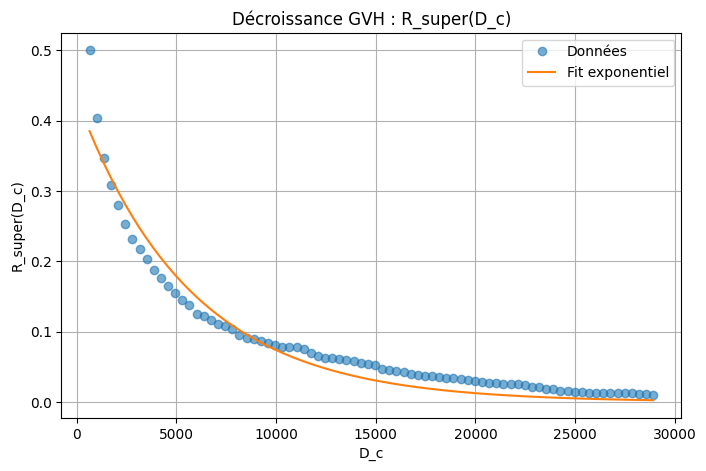

In [30]:
plt.figure(figsize=(8,5))

plt.plot(Dc_fit, R_fit, "o", alpha=0.6, label="Données")
plt.plot(Dc_fit, exp_model(Dc_fit, A_fit, B_H), "-", label="Fit exponentiel")

plt.xlabel("D_c")
plt.ylabel("R_super(D_c)")
plt.title("Décroissance GVH : R_super(D_c)")

plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Construction des vecteurs angulaires sur la sphère céleste

ra_rad = np.deg2rad(df_z["RA"].values)
dec_rad = np.deg2rad(df_z["DEC"].values)

x = np.cos(dec_rad) * np.cos(ra_rad)
y = np.cos(dec_rad) * np.sin(ra_rad)
z_sky = np.sin(dec_rad)

vectors = np.vstack([x, y, z_sky]).T

print("Vecteurs sphériques construits :", vectors.shape)

Vecteurs sphériques construits : (1464, 3)


In [32]:
# Angle entre directions successives dans le catalogue trié en redshift

dot_products = np.sum(vectors[:-1] * vectors[1:], axis=1)

# Correction numérique pour éviter arccos hors domaine

dot_products = np.clip(dot_products, -1.0, 1.0)

theta = np.rad2deg(np.arccos(dot_products))

theta_mean = np.mean(theta)
theta_max = np.max(theta)

# R_180 = fraction des angles proches de 180 degrés
# seuil choisi pour 0.1 : theta > 170 degrés

R_180 = np.mean(theta > 170)

print("theta_mean :", theta_mean)
print("theta_max :", theta_max)
print("R_180 :", R_180)

theta_mean : 73.21715142855119
theta_max : 177.3210444574389
R_180 : 0.004101161995898838


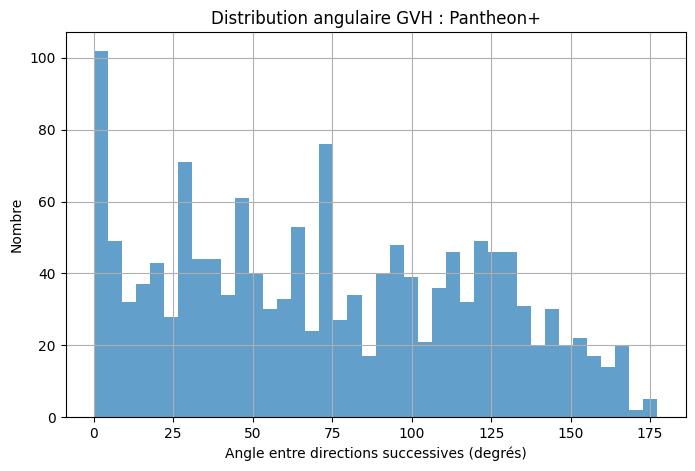

In [33]:
plt.figure(figsize=(8,5))

plt.hist(theta, bins=40, alpha=0.7)

plt.xlabel("Angle entre directions successives (degrés)")
plt.ylabel("Nombre")
plt.title("Distribution angulaire GVH : Pantheon+")

plt.grid(True)
plt.show()

In [34]:
df_z["theta_mean"] = theta_mean
df_z["theta_max"] = theta_max
df_z["R_180"] = R_180

print("Observables angulaires ajoutées.")

Observables angulaires ajoutées.


In [35]:
summary = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T_mean",
        "D_c",
        "R_super",
        "A_H",
        "B_H",
        "theta_mean",
        "theta_max",
        "R_180"
    ],
    "Valeur": [
        np.mean(D_T),
        np.mean(S_T),
        D_c,
        R_super,
        A_H,
        B_H,
        theta_mean,
        theta_max,
        R_180
    ]
})

summary

,Observable,Valeur
0,D_T_mean,2876.479948
1,S_T_mean,0.150536
2,D_c,12631.612237
3,R_super,0.062842
4,A_H,22166.616619
5,B_H,0.000176
6,theta_mean,73.217151
7,theta_max,177.321044
8,R_180,0.004101


## Discussion

Les observables GVH ont été construites directement à partir du catalogue Pantheon+.

Le pipeline fournit des quantités descriptives reproductibles sans faire appel à une interprétation physique spécifique.

Les paramètres obtenus pourront être comparés à ceux issus d'autres systèmes étudiés dans GVH Dynamic (Lorenz, Rössler, Duffing, H(z), BAO, CMB).

## Conclusion

Le notebook **GVH_Pantheon_Pipeline_0.1** met en œuvre un pipeline reproductible permettant de construire un ensemble d'observables géométriques multi-échelles à partir du catalogue Pantheon+.

Les principaux résultats obtenus sont :

- \(D_T\) moyen : 2876.48
- \(S_T\) moyen : 0.1505
- \(D_c\) : 12631.61
- \(R_{\rm super}\) : 0.06284
- \(A_H\) : 22166.62
- \(B_H\) : 0.000176
- \(\theta_{\rm mean}\) : 73.22°
- \(\theta_{\max}\) : 177.32°
- \(R_{180}\) : 0.00410

Cette version 0.1 est entièrement descriptive et reproductible. Elle construit les observables GVH directement à partir des données Pantheon+, sans introduire d'interprétation physique spécifique. Elle constitue une base méthodologique pouvant être réutilisée, comparée et étendue dans les versions ultérieures de **GVH Dynamic**.